# Breast Cancer Prediction System
**Dataset:** Wisconsin Diagnostic Breast Cancer (WDBC) | **Model:** Random Forest Classifier

In [11]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    ConfusionMatrixDisplay, f1_score
)

print('All imports successful.')

All imports successful.


In [12]:
# ── Cell 2: Load & Explore Dataset ────────────────────────────────────────────
data = load_breast_cancer()
X, y = data.data, data.target

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

print(f'Dataset shape : {X.shape}  ({X.shape[0]} samples, {X.shape[1]} features)')
print(f'Class balance : Benign={sum(y==1)}  Malignant={sum(y==0)}')
print()
df.head()

Dataset shape : (569, 30)  (569 samples, 30 features)
Class balance : Benign=357  Malignant=212



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [13]:
# ── Cell 3: Split FIRST, then Scale (fixes data leakage) ──────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit only on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

print(f'Train size : {X_train_scaled.shape[0]} samples')
print(f'Test size  : {X_test_scaled.shape[0]} samples')

Train size : 455 samples
Test size  : 114 samples


In [14]:
# ── Cell 4: Train Random Forest ───────────────────────────────────────────────
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_scaled, y_train)
print('Model trained successfully.')

Model trained successfully.


In [15]:
# ── Cell 5: Evaluate — Accuracy + Classification Report ───────────────────────
y_pred = model.predict(X_test_scaled)

print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

Accuracy : 0.9561
F1 Score : 0.9655

              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [16]:
# ── Cell 6: 10-Fold Cross-Validation ──────────────────────────────────────────
# Scale full dataset for CV evaluation
X_scaled_full = StandardScaler().fit_transform(X)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print(f"{'Metric':<12} {'Mean':>8} {'Std':>8} {'Min':>8}")
print('-' * 40)
for metric in ['accuracy', 'f1', 'recall', 'precision']:
    scores = cross_val_score(model, X_scaled_full, y, cv=cv, scoring=metric)
    print(f"{metric:<12} {scores.mean():>8.4f} {scores.std():>8.4f} {scores.min():>8.4f}")

Metric           Mean      Std      Min
----------------------------------------


accuracy       0.9544   0.0296   0.8947
f1             0.9641   0.0228   0.9211
recall         0.9692   0.0317   0.8889
precision      0.9605   0.0378   0.8750


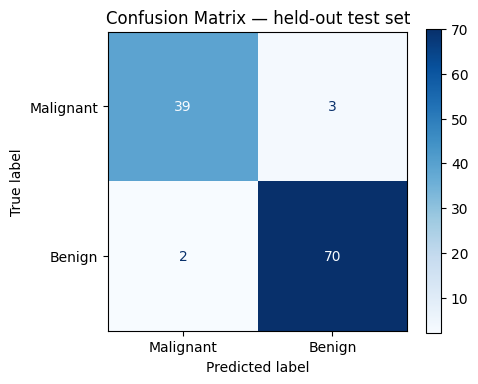

In [17]:
# ── Cell 7: Confusion Matrix ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    model, X_test_scaled, y_test,
    display_labels=['Malignant', 'Benign'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — held-out test set')
plt.tight_layout()
plt.show()

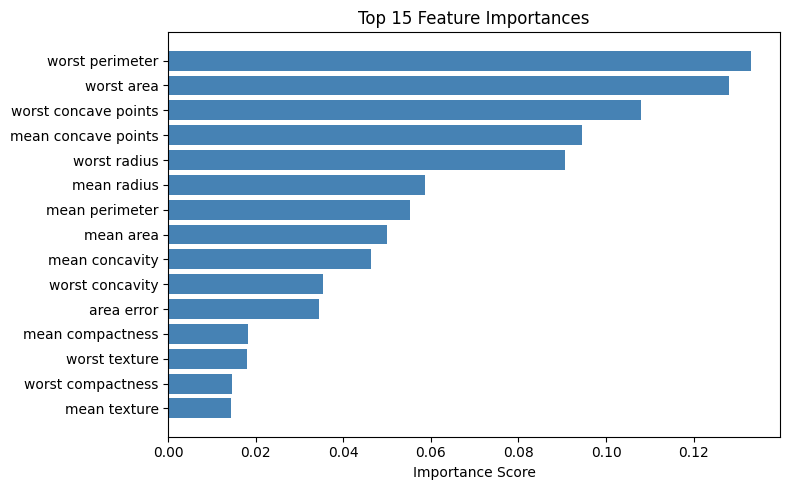

In [18]:
# ── Cell 8: Feature Importance (Top 15) ───────────────────────────────────────
importances = model.feature_importances_
indices = np.argsort(importances)[::-1][:15]
feat_names = [data.feature_names[i] for i in indices]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(feat_names[::-1], importances[indices][::-1], color='steelblue')
ax.set_xlabel('Importance Score')
ax.set_title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

In [19]:
# ── Cell 9: Retrain on Full Data & Save ───────────────────────────────────────
# Retrain on ALL 569 samples for the best possible deployed model
final_scaler = StandardScaler()
X_all_scaled = final_scaler.fit_transform(X)

final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_all_scaled, y)

pickle.dump(final_model, open('../model.pkl', 'wb'))
pickle.dump(final_scaler, open('../scaler.pkl', 'wb'))

print(f'Model trained on {X_all_scaled.shape[0]}/{X.shape[0]} samples')
print('Saved: ../model.pkl')
print('Saved: ../scaler.pkl')

Model trained on 569/569 samples
Saved: ../model.pkl
Saved: ../scaler.pkl
